## 1. Import Required Libraries

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Create output directory
os.makedirs('eda_output', exist_ok=True)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.2


## 2. Load the Dataset

In [7]:
# Load bills data
df_bills = pd.read_csv('data_export/bills.csv')
df_searches = pd.read_csv('data_export/search_history.csv')

print("="*60)
print("DATASET LOADED")
print("="*60)
print(f"\nBills Dataset Shape: {df_bills.shape}")
print(f"Search History Shape: {df_searches.shape}")
print(f"\nBills Columns ({len(df_bills.columns)}):")
print(df_bills.columns.tolist())
print(f"\nMemory Usage: {df_bills.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET LOADED

Bills Dataset Shape: (938, 17)
Search History Shape: (57, 5)

Bills Columns (17):
['id', 'bill_id', 'title', 'ministry', 'status', 'url', 'introduction_date', 'date_scraped', 'last_updated', 'has_content', 'has_summary', 'content_length', 'num_sections', 'num_paragraphs', 'has_pdf', 'summary_length', 'summary_type']

Memory Usage: 0.68 MB


## 3. Initial Data Inspection

In [8]:
# Display first few rows
print("First 5 Bills:")
print("="*60)
df_bills.head()

First 5 Bills:


,id,bill_id,title,ministry,status,url,introduction_date,date_scraped,last_updated,has_content,has_summary,content_length,num_sections,num_paragraphs,has_pdf,summary_length,summary_type
0,1,the-government-of-union-territories-amendment-...,The Government of Union Territories (Amendment...,Home Affairs,In Committee,https://prsindia.org/billtrack/the-government-...,2025-08-20T00:00:00,2025-11-11T14:39:52.948600,2025-11-20T00:35:57.554064,True,False,2359,0,0,True,0,NaN
1,2,the-jammu-and-kashmir-reorganisation-amendment...,The Jammu and Kashmir Reorganisation (Amendmen...,Home Affairs,In Committee,https://prsindia.org/billtrack/the-jammu-and-k...,2025-08-20T00:00:00,2025-11-11T14:39:52.953938,2025-11-20T00:35:58.712244,True,False,2357,0,0,True,0,NaN
2,3,the-constitution-one-hundred-and-thirtieth-ame...,The Constitution (One Hundred and Thirtieth Am...,Home Affairs,In Committee,https://prsindia.org/billtrack/the-constitutio...,2025-08-20T00:00:00,2025-11-11T14:39:52.955643,2025-11-20T00:35:59.835028,True,False,2374,0,0,True,0,NaN
3,4,the-promotion-and-regulation-of-online-gaming-...,The Promotion and Regulation of Online Gaming ...,Electronics and Information Technology,Passed,https://prsindia.org/billtrack/the-promotion-a...,2025-08-20T00:00:00,2025-11-11T14:39:52.956859,2025-11-20T00:36:00.955434,True,True,4698,0,3,True,1243,api_llm
4,5,the-jan-vishwas-amendment-of-provisions-bill-2025,The Jan Vishwas (Amendment of Provisions) Bill...,Commerce and Industry,In Committee,https://prsindia.org/billtrack/the-jan-vishwas...,2025-08-18T00:00:00,2025-11-11T14:39:52.957952,2025-11-20T00:36:02.184498,True,False,4696,0,0,True,0,NaN


In [9]:
# Display data types and info
print("Dataset Info:")
print("="*60)
df_bills.info()

print("\n" + "="*60)
print("Basic Statistics:")
print("="*60)
df_bills.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 938 non-null    int64 
 1   bill_id            938 non-null    object
 2   title              938 non-null    object
 3   ministry           938 non-null    object
 4   status             937 non-null    object
 5   url                938 non-null    object
 6   introduction_date  801 non-null    object
 7   date_scraped       938 non-null    object
 8   last_updated       938 non-null    object
 9   has_content        938 non-null    bool  
 10  has_summary        938 non-null    bool  
 11  content_length     938 non-null    int64 
 12  num_sections       938 non-null    int64 
 13  num_paragraphs     938 non-null    int64 
 14  has_pdf            938 non-null    bool  
 15  summary_length     938 non-null    int64 
 16  summary_type       4 non-null 

,id,content_length,num_sections,num_paragraphs,summary_length
count,938.000000,938.000000,938.0,938.000000,938.000000
mean,469.500000,4723.003198,0.0,0.072495,3.700426
std,270.921575,6991.251017,0.0,1.144366,63.945905
min,1.000000,137.000000,0.0,0.000000,0.000000
25%,235.250000,1468.000000,0.0,0.000000,0.000000
50%,469.500000,2329.000000,0.0,0.000000,0.000000
75%,703.750000,4383.500000,0.0,0.000000,0.000000
max,938.000000,63673.000000,0.0,32.000000,1243.000000


## 4. Missing Values Analysis

MISSING DATA ANALYSIS

Missing Values by Column:
                   Missing Count  Percentage (%)
summary_type                 934           99.57
introduction_date            137           14.61
status                         1            0.11



Saved: eda_output/missing_data.png


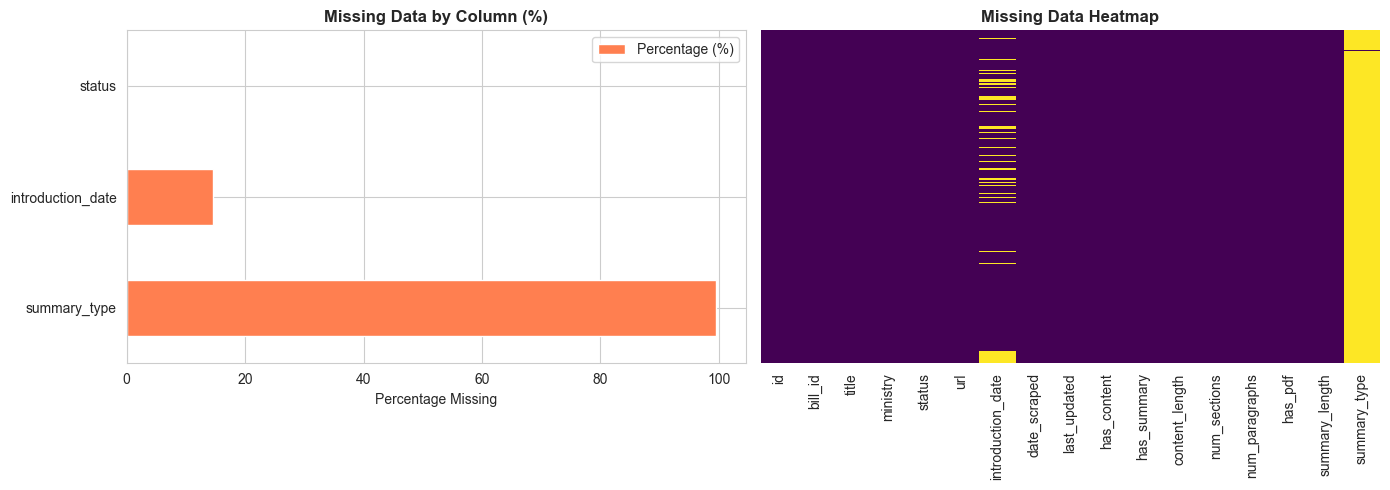

In [10]:
# Missing data analysis
print("MISSING DATA ANALYSIS")
print("="*60)

missing = df_bills.isnull().sum()
missing_pct = (missing / len(df_bills) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print("\nMissing Values by Column:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing data
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
missing_df[missing_df['Missing Count'] > 0].plot(kind='barh', y='Percentage (%)', ax=ax[0], color='coral')
ax[0].set_title('Missing Data by Column (%)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Percentage Missing')

# Heatmap
sns.heatmap(df_bills.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax[1])
ax[1].set_title('Missing Data Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_output/missing_data.png', dpi=300, bbox_inches='tight')
print("\nSaved: eda_output/missing_data.png")
plt.show()

## 5. Ministry Distribution Analysis

MINISTRY ANALYSIS

Total Bills: 938
Bills with known ministry: 786
Bills with Unknown ministry: 152
Unique Ministries: 66

Top 15 Ministries:
ministry_clean
Law and Justice                           130
Finance                                   114
Home Affairs                               70
Human Resource Development                 42
Health                                     28
Health and Family Welfare                  26
Labour                                     22
Personnel, Grievances and Pensions         18
Consumer Affairs and Food Distribution     18
Tribal Affairs                             17
Labour and Employment                      15
Urban Development                          14
Shipping                                   14
Mines                                      14
Social Justice and Welfare                 14
Name: count, dtype: int64

Saved: eda_output/top_ministries.png

Saved: eda_output/top_ministries.png


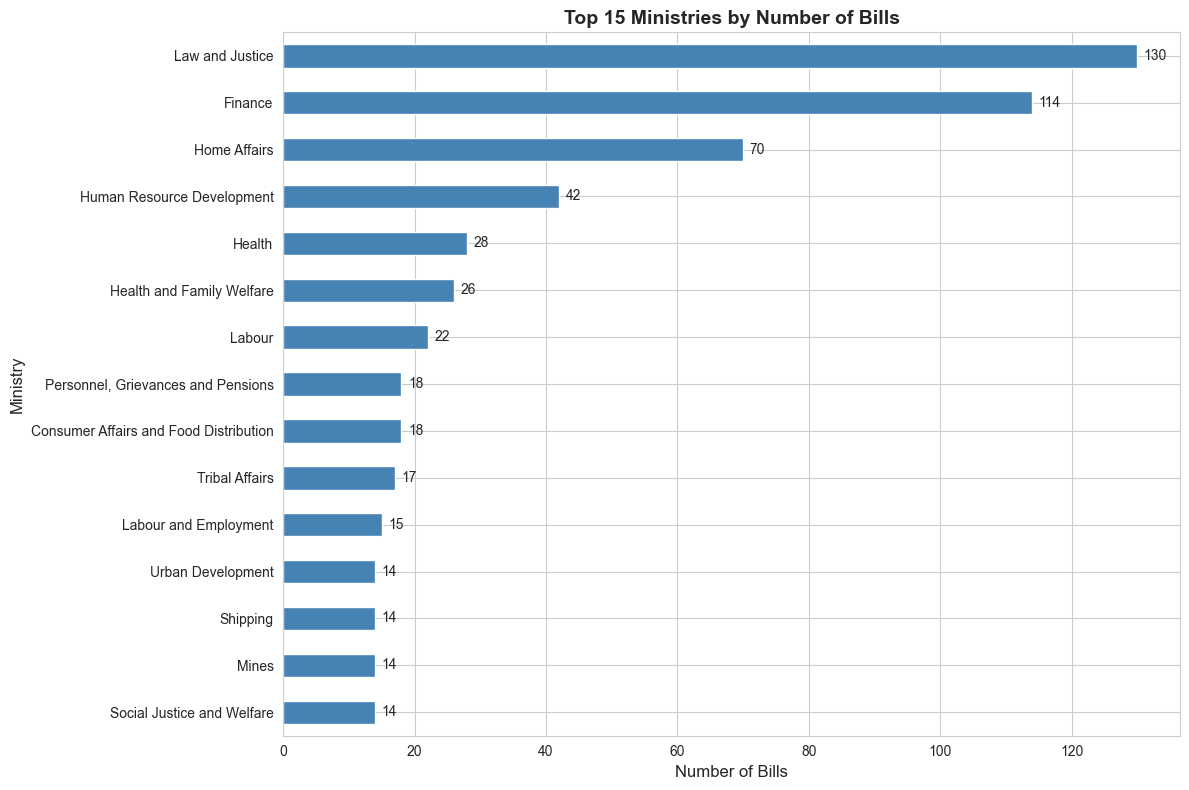

In [11]:
# Clean ministry names
df_bills['ministry_clean'] = df_bills['ministry'].fillna('Unknown').str.replace('Ministry:', '').str.strip()

print("MINISTRY ANALYSIS")
print("="*60)
print(f"\nTotal Bills: {len(df_bills)}")
print(f"Bills with known ministry: {(df_bills['ministry_clean'] != 'Unknown').sum()}")
print(f"Bills with Unknown ministry: {(df_bills['ministry_clean'] == 'Unknown').sum()}")
print(f"Unique Ministries: {df_bills[df_bills['ministry_clean'] != 'Unknown']['ministry_clean'].nunique()}")

# Top 15 ministries
top_ministries = df_bills[df_bills['ministry_clean'] != 'Unknown']['ministry_clean'].value_counts().head(15)
print("\nTop 15 Ministries:")
print(top_ministries)

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
top_ministries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Ministries by Number of Bills', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Bills', fontsize=12)
ax.set_ylabel('Ministry', fontsize=12)
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(top_ministries):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_output/top_ministries.png', dpi=300, bbox_inches='tight')
print("\nSaved: eda_output/top_ministries.png")
plt.show()

## 6. Bill Status Distribution

BILL STATUS ANALYSIS

Status Distribution:
status
Passed                  539
Lapsed                  168
Withdrawn                88
Replaced by an Act       61
Draft                    46
Pending                  19
In Committee              7
Rules                     5
Model Act                 1
Repromulgated             1
Negatived                 1
Introduced-Negatived      1
Name: count, dtype: int64

Bill Lifecycle Metrics:
   Passed: 539 (57.5%)
   Lapsed: 168 (17.9%)
   Withdrawn: 88 (9.4%)
   Pending: 19 (2.0%)
   Success Rate: 67.8%

Saved: eda_output/bill_status_distribution.png

Saved: eda_output/bill_status_distribution.png


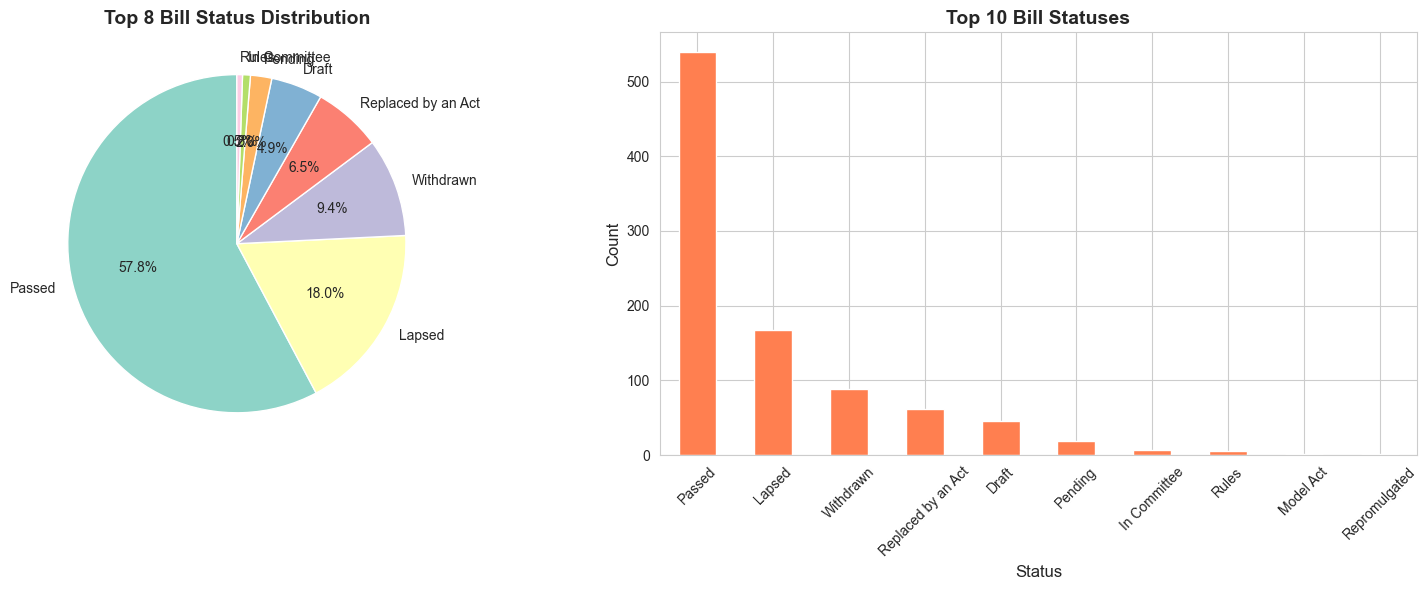

In [12]:
print("BILL STATUS ANALYSIS")
print("="*60)

status_counts = df_bills['status'].value_counts()
print("\nStatus Distribution:")
print(status_counts)

# Calculate success metrics
passed = (df_bills['status'] == 'Passed').sum()
lapsed = (df_bills['status'] == 'Lapsed').sum()
withdrawn = (df_bills['status'] == 'Withdrawn').sum()
pending = (df_bills['status'] == 'Pending').sum()

print(f"\nBill Lifecycle Metrics:")
print(f"   Passed: {passed} ({passed/len(df_bills)*100:.1f}%)")
print(f"   Lapsed: {lapsed} ({lapsed/len(df_bills)*100:.1f}%)")
print(f"   Withdrawn: {withdrawn} ({withdrawn/len(df_bills)*100:.1f}%)")
print(f"   Pending: {pending} ({pending/len(df_bills)*100:.1f}%)")
print(f"   Success Rate: {passed/(passed+lapsed+withdrawn)*100:.1f}%")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for top 8 statuses
top_status = status_counts.head(8)
colors = plt.cm.Set3(range(len(top_status)))
ax[0].pie(top_status, labels=top_status.index, autopct='%1.1f%%', startangle=90, colors=colors)
ax[0].set_title('Top 8 Bill Status Distribution', fontsize=14, fontweight='bold')

# Bar chart
status_counts.head(10).plot(kind='bar', ax=ax[1], color='coral')
ax[1].set_title('Top 10 Bill Statuses', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Status', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_output/bill_status_distribution.png', dpi=300, bbox_inches='tight')
print("\nSaved: eda_output/bill_status_distribution.png")
plt.show()

## 7. Ministry vs Status Cross-Analysis

MINISTRY vs STATUS CROSS-ANALYSIS

Top 10 Ministries - Status Distribution:
status                                  Draft  In Committee  \
ministry_clean                                                
Law and Justice                             0             2   
Finance                                     4             1   
Home Affairs                                0             3   
Human Resource Development                  3             0   
Health                                      0             0   
Health and Family Welfare                   1             0   
Labour                                      0             0   
Personnel, Grievances and Pensions          0             0   
Consumer Affairs and Food Distribution      1             0   
Tribal Affairs                              0             0   

status                                  Introduced-Negatived  Lapsed  \
ministry_clean                                                         
Law and Justice        

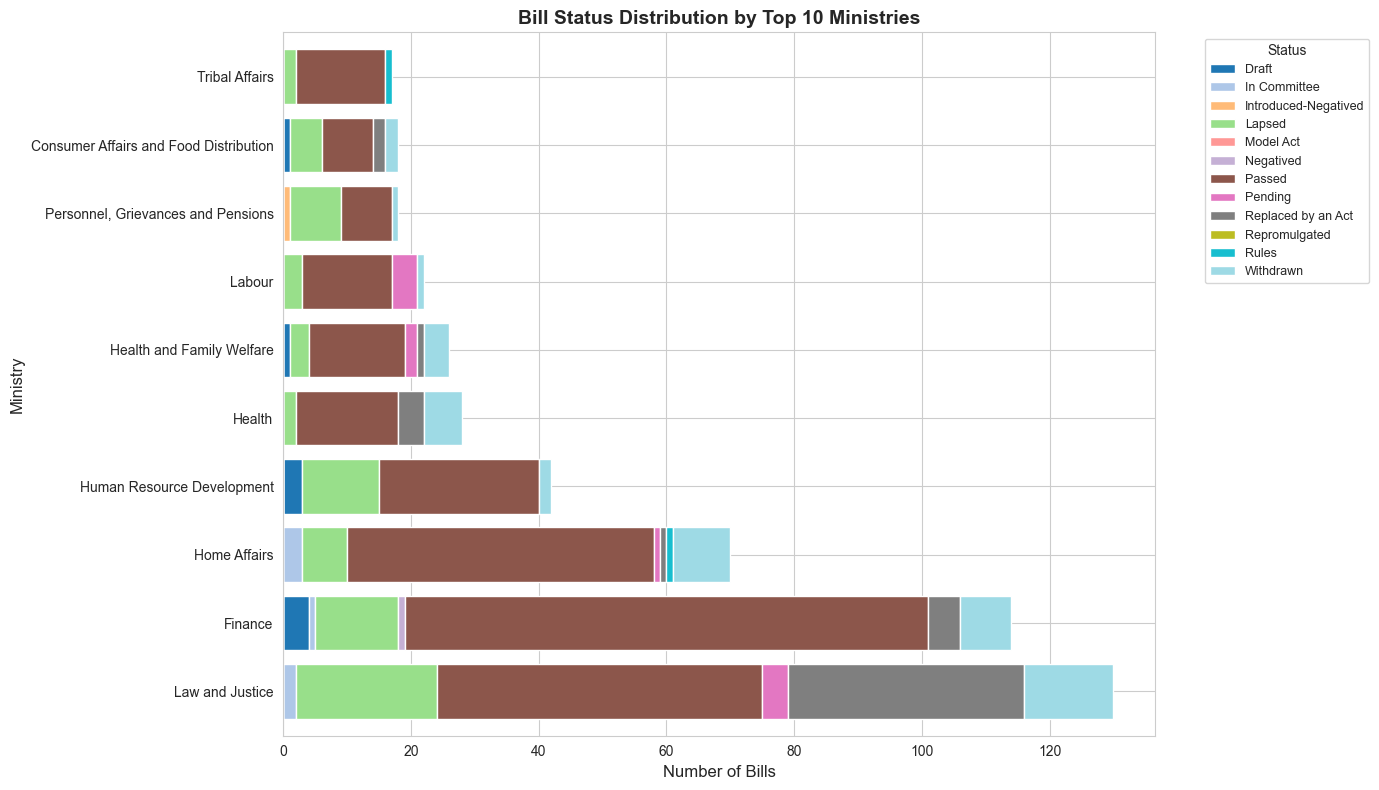

In [13]:
# Cross-tabulation: Ministry vs Status
ministry_status = pd.crosstab(
    df_bills[df_bills['ministry_clean'] != 'Unknown']['ministry_clean'],
    df_bills['status']
)

# Top 10 ministries
top_10_ministries = df_bills[df_bills['ministry_clean'] != 'Unknown']['ministry_clean'].value_counts().head(10).index
ministry_status_top = ministry_status.loc[top_10_ministries]

print("MINISTRY vs STATUS CROSS-ANALYSIS")
print("="*60)
print("\nTop 10 Ministries - Status Distribution:")
print(ministry_status_top)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
ministry_status_top.plot(kind='barh', stacked=True, ax=ax, width=0.8, colormap='tab20')
ax.set_title('Bill Status Distribution by Top 10 Ministries', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Bills', fontsize=12)
ax.set_ylabel('Ministry', fontsize=12)
ax.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('eda_output/ministry_status_distribution.png', dpi=300, bbox_inches='tight')
print("\nSaved: eda_output/ministry_status_distribution.png")
plt.show()

## 8. Ministry Success Rate Analysis

MINISTRY SUCCESS RATE ANALYSIS

Overall Statistics:
   Total Ministries: 66
   Ministries with ≥5 decided bills: 34
   Average Success Rate: 68.0%
   Median Success Rate: 67.5%

Lowest 10 Ministries by Success Rate (≥5 decided bills):

Roads
   Success Rate: 37.5%
   Bills: 3 passed / 8 decided (Total: 8)
   Status: 3P / 3L / 2W / 0Pending

Rural Development
   Success Rate: 37.5%
   Bills: 3 passed / 8 decided (Total: 10)
   Status: 3P / 5L / 0W / 1Pending

Culture
   Success Rate: 40.0%
   Bills: 2 passed / 5 decided (Total: 5)
   Status: 2P / 2L / 1W / 0Pending

Water Resources
   Success Rate: 40.0%
   Bills: 2 passed / 5 decided (Total: 7)
   Status: 2P / 3L / 0W / 0Pending

Personnel, Grievances and Pensions
   Success Rate: 47.1%
   Bills: 8 passed / 17 decided (Total: 18)
   Status: 8P / 8L / 1W / 0Pending

Agriculture
   Success Rate: 50.0%
   Bills: 3 passed / 6 decided (Total: 8)
   Status: 3P / 3L / 0W / 1Pending

Consumer Affairs and Food Distribution
   Success Rate: 53.3

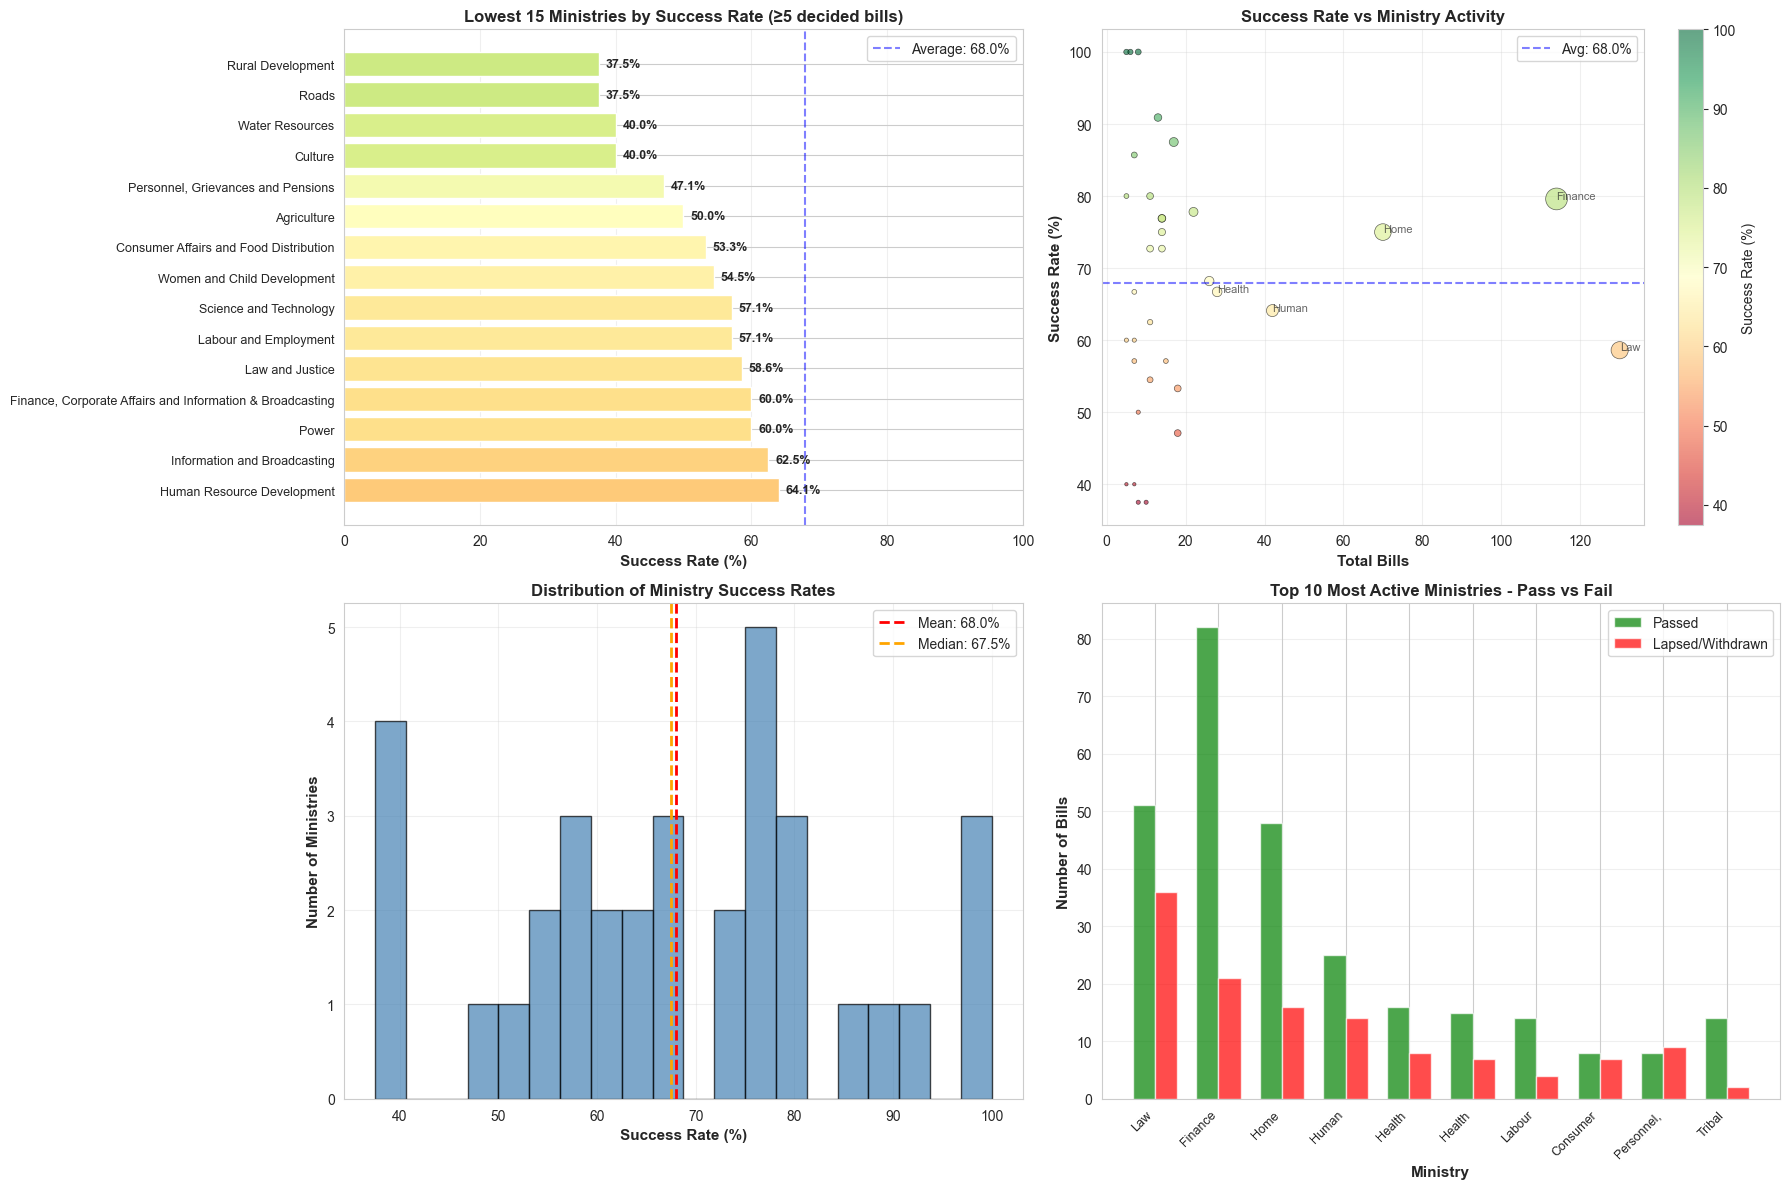

In [24]:
print("MINISTRY SUCCESS RATE ANALYSIS")
print("="*70)

# Filter out Unknown ministries
known_ministries = df_bills[df_bills['ministry_clean'] != 'Unknown'].copy()

# Calculate success metrics for each ministry
ministry_stats = []

for ministry in known_ministries['ministry_clean'].unique():
    ministry_bills = known_ministries[known_ministries['ministry_clean'] == ministry]
    
    total = len(ministry_bills)
    passed = (ministry_bills['status'] == 'Passed').sum()
    lapsed = (ministry_bills['status'] == 'Lapsed').sum()
    withdrawn = (ministry_bills['status'] == 'Withdrawn').sum()
    pending = (ministry_bills['status'] == 'Pending').sum()
    
    # Success rate = Passed / (Passed + Lapsed + Withdrawn)
    # Excluding pending bills from calculation
    decided_bills = passed + lapsed + withdrawn
    success_rate = (passed / decided_bills * 100) if decided_bills > 0 else 0
    
    ministry_stats.append({
        'Ministry': ministry,
        'Total Bills': total,
        'Passed': passed,
        'Lapsed': lapsed,
        'Withdrawn': withdrawn,
        'Pending': pending,
        'Decided Bills': decided_bills,
        'Success Rate (%)': round(success_rate, 1)
    })

# Create DataFrame and sort by success rate
df_ministry_success = pd.DataFrame(ministry_stats)
df_ministry_success = df_ministry_success.sort_values('Success Rate (%)', ascending=False)

# Filter ministries with at least 5 decided bills for meaningful analysis
df_ministry_success_filtered = df_ministry_success[df_ministry_success['Decided Bills'] >= 5].copy()

print(f"\nOverall Statistics:")
print(f"   Total Ministries: {len(df_ministry_success)}")
print(f"   Ministries with ≥5 decided bills: {len(df_ministry_success_filtered)}")
print(f"   Average Success Rate: {df_ministry_success_filtered['Success Rate (%)'].mean():.1f}%")
print(f"   Median Success Rate: {df_ministry_success_filtered['Success Rate (%)'].median():.1f}%")

print(f"\nLowest 10 Ministries by Success Rate (≥5 decided bills):")
print("="*70)
lowest_10 = df_ministry_success_filtered.tail(10).sort_values('Success Rate (%)', ascending=True)
for idx, row in lowest_10.iterrows():
    print(f"\n{row['Ministry']}")
    print(f"   Success Rate: {row['Success Rate (%)']}%")
    print(f"   Bills: {row['Passed']} passed / {row['Decided Bills']} decided (Total: {row['Total Bills']})")
    print(f"   Status: {row['Passed']}P / {row['Lapsed']}L / {row['Withdrawn']}W / {row['Pending']}Pending")

print(f"\nHighest 10 Ministries by Success Rate (≥5 decided bills):")
print("="*70)
for idx, row in df_ministry_success_filtered.head(10).iterrows():
    print(f"\n{row['Ministry']}")
    print(f"   Success Rate: {row['Success Rate (%)']}%")
    print(f"   Bills: {row['Passed']} passed / {row['Decided Bills']} decided (Total: {row['Total Bills']})")
    print(f"   Status: {row['Passed']}P / {row['Lapsed']}L / {row['Withdrawn']}W / {row['Pending']}Pending")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Lowest 15 Ministries by Success Rate
ax1 = axes[0, 0]
lowest_15_success = df_ministry_success_filtered.tail(15).sort_values('Success Rate (%)', ascending=True)
colors = plt.cm.RdYlGn_r(lowest_15_success['Success Rate (%)'] / 100)
bars = ax1.barh(range(len(lowest_15_success)), lowest_15_success['Success Rate (%)'], color=colors)
ax1.set_yticks(range(len(lowest_15_success)))
ax1.set_yticklabels(lowest_15_success['Ministry'], fontsize=9)
ax1.set_xlabel('Success Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Lowest 15 Ministries by Success Rate (≥5 decided bills)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(0, 100)
ax1.axvline(df_ministry_success_filtered['Success Rate (%)'].mean(), color='blue', linestyle='--', 
            alpha=0.5, label=f'Average: {df_ministry_success_filtered["Success Rate (%)"].mean():.1f}%')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
# Add value labels
for i, v in enumerate(lowest_15_success['Success Rate (%)']):
    ax1.text(v + 1, i, f'{v}%', va='center', fontsize=9, fontweight='bold')

# 2. Success Rate vs Total Bills (Scatter)
ax2 = axes[0, 1]
scatter = ax2.scatter(df_ministry_success_filtered['Total Bills'], 
                     df_ministry_success_filtered['Success Rate (%)'],
                     s=df_ministry_success_filtered['Passed']*3,
                     c=df_ministry_success_filtered['Success Rate (%)'],
                     cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Total Bills', fontsize=11, fontweight='bold')
ax2.set_ylabel('Success Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Success Rate vs Ministry Activity', fontsize=12, fontweight='bold')
ax2.axhline(df_ministry_success_filtered['Success Rate (%)'].mean(), color='blue', 
            linestyle='--', alpha=0.5, label=f'Avg: {df_ministry_success_filtered["Success Rate (%)"].mean():.1f}%')
ax2.legend()
ax2.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Success Rate (%)')

# Annotate top 5 ministries by total bills
top_5_active = df_ministry_success_filtered.nlargest(5, 'Total Bills')
for _, row in top_5_active.iterrows():
    ax2.annotate(row['Ministry'].split()[0], 
                (row['Total Bills'], row['Success Rate (%)']),
                fontsize=8, alpha=0.7)

# 3. Success Rate Distribution (Histogram)
ax3 = axes[1, 0]
ax3.hist(df_ministry_success_filtered['Success Rate (%)'], bins=20, 
         edgecolor='black', color='steelblue', alpha=0.7)
ax3.axvline(df_ministry_success_filtered['Success Rate (%)'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {df_ministry_success_filtered["Success Rate (%)"].mean():.1f}%')
ax3.axvline(df_ministry_success_filtered['Success Rate (%)'].median(), color='orange', 
            linestyle='--', linewidth=2, label=f'Median: {df_ministry_success_filtered["Success Rate (%)"].median():.1f}%')
ax3.set_xlabel('Success Rate (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Ministries', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Ministry Success Rates', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Top 10 Ministries - Passed vs Failed
ax4 = axes[1, 1]
top_10_active = df_ministry_success_filtered.nlargest(10, 'Total Bills')
top_10_active['Failed'] = top_10_active['Lapsed'] + top_10_active['Withdrawn']

x = range(len(top_10_active))
width = 0.35

bars1 = ax4.bar([i - width/2 for i in x], top_10_active['Passed'], width, 
                label='Passed', color='green', alpha=0.7)
bars2 = ax4.bar([i + width/2 for i in x], top_10_active['Failed'], width,
                label='Lapsed/Withdrawn', color='red', alpha=0.7)

ax4.set_xlabel('Ministry', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Bills', fontsize=11, fontweight='bold')
ax4.set_title('Top 10 Most Active Ministries - Pass vs Fail', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([m.split()[0] for m in top_10_active['Ministry']], rotation=45, ha='right', fontsize=9)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_output/ministry_success_rate.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_output/ministry_success_rate.png")
print("\nSaved: eda_output/ministry_success_rate.png")

# Summary insights
print(f"\n" + "="*70)
print("🎯 KEY INSIGHTS")
print("KEY INSIGHTS")

highest = df_ministry_success_filtered.iloc[0]
lowest = df_ministry_success_filtered.iloc[-1]
most_active = df_ministry_success_filtered.nlargest(1, 'Total Bills').iloc[0]

print(f"\n🏆 Highest Success Rate:")
print(f"\nHighest Success Rate:")
print(f"   {highest['Ministry']}: {highest['Success Rate (%)']}%")
print(f"   {highest['Passed']}/{highest['Decided Bills']} bills passed")
print(f"\n📉 Lowest Success Rate:")
print(f"\nLowest Success Rate:")
print(f"   {lowest['Ministry']}: {lowest['Success Rate (%)']}%")
print(f"   {lowest['Passed']}/{lowest['Decided Bills']} bills passed")
print(f"\n📊 Most Active Ministry:")
print(f"\nMost Active Ministry:")
print(f"   {most_active['Ministry']}: {most_active['Total Bills']} total bills")
print(f"   Success Rate: {most_active['Success Rate (%)']}%")
print(f"   {most_active['Passed']} passed, {most_active['Lapsed']} lapsed, {most_active['Withdrawn']} withdrawn")
# Export to CSV
df_ministry_success.to_csv('eda_output/ministry_success_rates.csv', index=False)
print(f"\n✅ Exported: eda_output/ministry_success_rates.csv")

📅 TEMPORAL DISTRIBUTION ANALYSIS

Bills with introduction year: 801 / 938 (85.4%)
Year Range: 1992 - 2025 (34 years)

📊 Bills Distribution:
   • Total years covered: 30
   • Average bills per year: 26.7
   • Most active year: 2019.0 (69 bills)
   • Least active year: 1992.0 (1 bills)

📊 Top 10 Years with Most Bills:
   - 2019: 69 bills
   - 2010: 60 bills
   - 2011: 50 bills
   - 2008: 47 bills
   - 2013: 46 bills
   - 2017: 45 bills
   - 2007: 42 bills
   - 2014: 40 bills
   - 2021: 39 bills
   - 2023: 39 bills

📊 Bills by Decade:
   - 1990s: 7 bills (0.9%)
   - 2000s: 186 bills (23.2%)
   - 2010s: 440 bills (54.9%)
   - 2020s: 168 bills (21.0%)

✅ Saved: eda_output/temporal_distribution.png


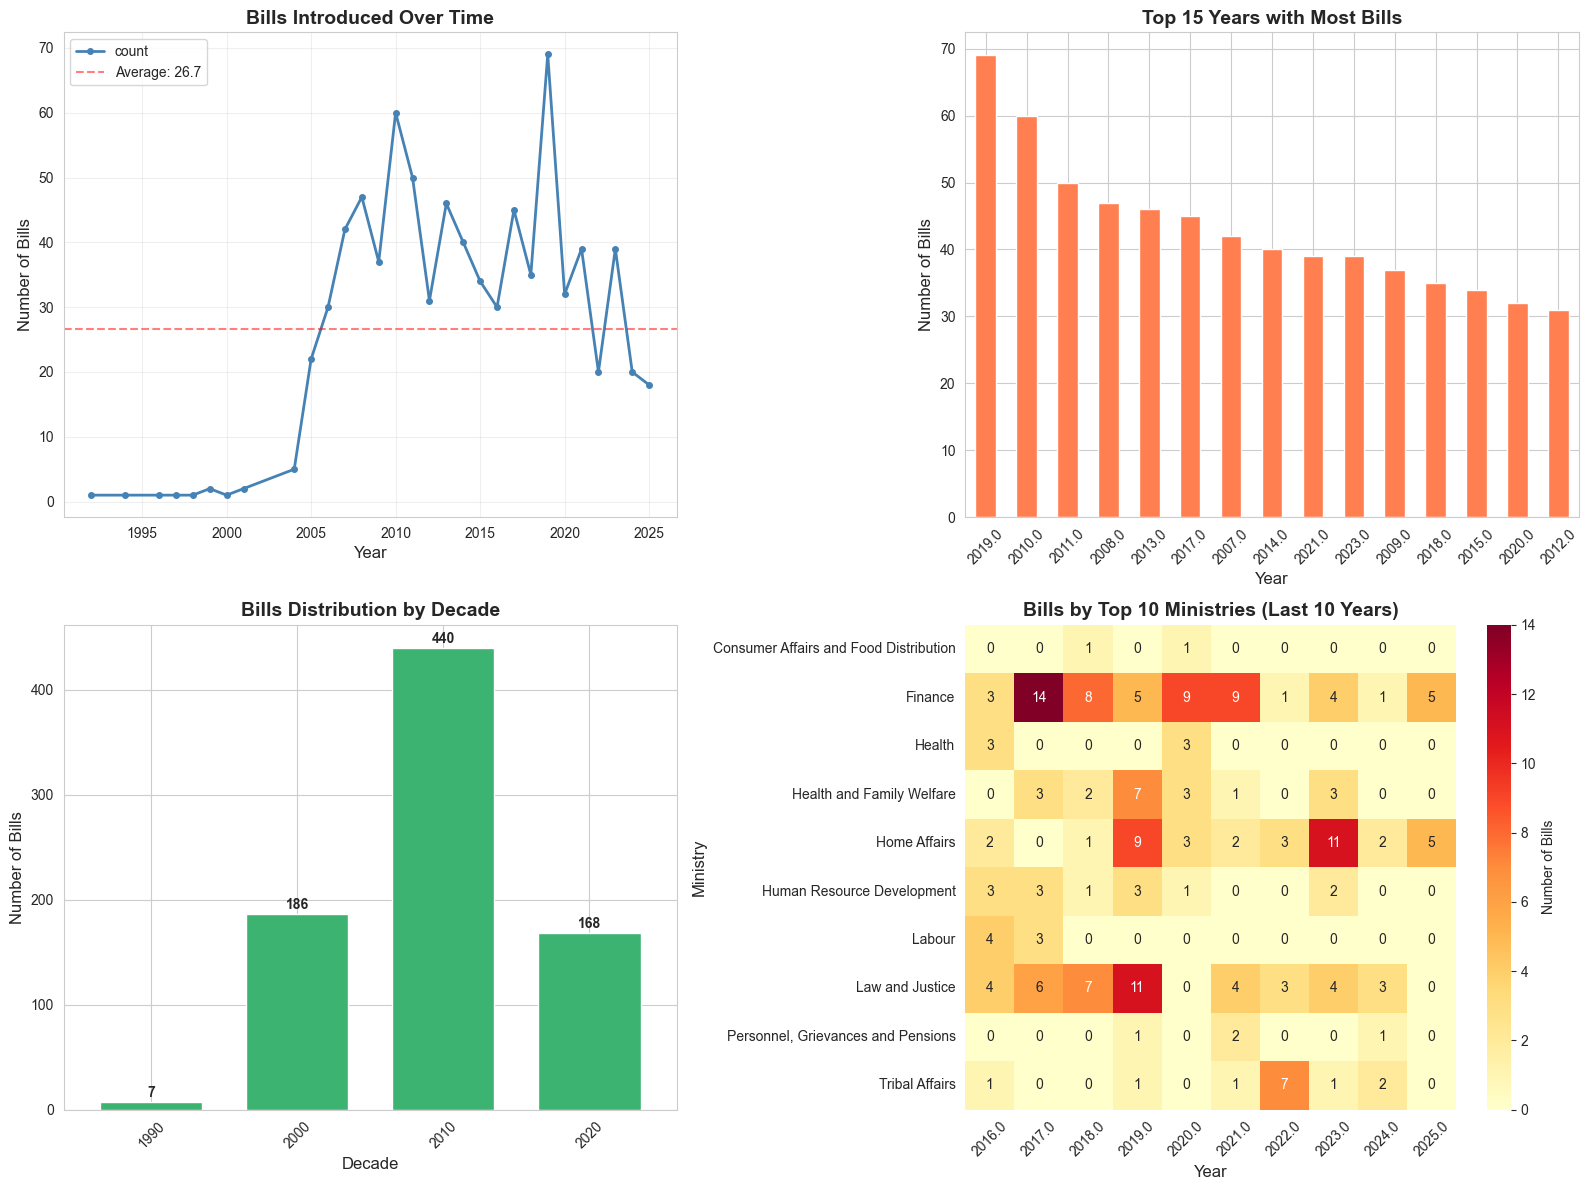


📈 Recent Trends (Last 5 Years: 2021-2025):
   • Total bills: 136
   • Average per year: 27.2
   • Top 3 ministries in recent years:
     - Home Affairs: 23 bills
     - Finance: 20 bills
     - Law and Justice: 14 bills


In [ ]:
print("📅 TEMPORAL DISTRIBUTION ANALYSIS")
print("="*60)

# Extract year from introduction_date
df_bills['year'] = pd.to_datetime(df_bills['introduction_date'], errors='coerce').dt.year

# Bills with valid years
bills_with_year = df_bills[df_bills['year'].notna()]
print(f"\nBills with introduction year: {len(bills_with_year)} / {len(df_bills)} ({len(bills_with_year)/len(df_bills)*100:.1f}%)")

if len(bills_with_year) > 0:
    # Year range
    min_year = int(bills_with_year['year'].min())
    max_year = int(bills_with_year['year'].max())
    print(f"Year Range: {min_year} - {max_year} ({max_year - min_year + 1} years)")
    
    # Decade classification
    df_bills['decade'] = (df_bills['year'] // 10 * 10).astype('Int64')
    
    # Bills by year
    bills_by_year = bills_with_year['year'].value_counts().sort_index()
    print(f"\n📊 Bills Distribution:")
    print(f"   • Total years covered: {bills_by_year.count()}")
    print(f"   • Average bills per year: {bills_by_year.mean():.1f}")
    print(f"   • Most active year: {bills_by_year.idxmax()} ({bills_by_year.max()} bills)")
    print(f"   • Least active year: {bills_by_year.idxmin()} ({bills_by_year.min()} bills)")
    
    # Top 10 years
    print(f"\n📊 Top 10 Years with Most Bills:")
    top_years = bills_by_year.nlargest(10)
    for year, count in top_years.items():
        print(f"   - {int(year)}: {count} bills")
    
    # Decade analysis
    decade_counts = df_bills[df_bills['decade'].notna()]['decade'].value_counts().sort_index()
    print(f"\n📊 Bills by Decade:")
    for decade, count in decade_counts.items():
        print(f"   - {int(decade)}s: {count} bills ({count/len(bills_with_year)*100:.1f}%)")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Line plot: Bills over time
    ax1 = axes[0, 0]
    bills_by_year.plot(kind='line', ax=ax1, color='steelblue', linewidth=2, marker='o', markersize=4)
    ax1.set_title('Bills Introduced Over Time', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Number of Bills', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(bills_by_year.mean(), color='red', linestyle='--', alpha=0.5, label=f'Average: {bills_by_year.mean():.1f}')
    ax1.legend()
    
    # 2. Bar plot: Top 15 years
    ax2 = axes[0, 1]
    top_15_years = bills_by_year.nlargest(15)
    top_15_years.plot(kind='bar', ax=ax2, color='coral')
    ax2.set_title('Top 15 Years with Most Bills', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Number of Bills', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. Decade distribution
    ax3 = axes[1, 0]
    decade_counts.plot(kind='bar', ax=ax3, color='mediumseagreen', width=0.7)
    ax3.set_title('Bills Distribution by Decade', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Decade', fontsize=12)
    ax3.set_ylabel('Number of Bills', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
    # Add value labels
    for i, v in enumerate(decade_counts):
        ax3.text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
    
    # 4. Ministry vs Year heatmap (top 10 ministries, last 10 years)
    ax4 = axes[1, 1]
    recent_years = sorted(bills_with_year['year'].unique())[-10:]
    top_10_ministries_list = df_bills[df_bills['ministry_clean'] != 'Unknown']['ministry_clean'].value_counts().head(10).index
    
    # Create pivot table
    heatmap_data = df_bills[
        (df_bills['year'].isin(recent_years)) & 
        (df_bills['ministry_clean'].isin(top_10_ministries_list))
    ].pivot_table(
        index='ministry_clean',
        columns='year',
        values='id',
        aggfunc='count',
        fill_value=0
    )
    
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Number of Bills'})
    ax4.set_title(f'Bills by Top 10 Ministries (Last 10 Years)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Year', fontsize=12)
    ax4.set_ylabel('Ministry', fontsize=12)
    ax4.tick_params(axis='x', rotation=45)
    ax4.tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.savefig('eda_output/temporal_distribution.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_output/temporal_distribution.png")
    plt.show()
    
    # Recent trends (last 5 years)
    recent_5_years = sorted(bills_with_year['year'].unique())[-5:]
    recent_bills = df_bills[df_bills['year'].isin(recent_5_years)]
    print(f"\n📈 Recent Trends (Last 5 Years: {int(min(recent_5_years))}-{int(max(recent_5_years))}):")
    print(f"   • Total bills: {len(recent_bills)}")
    print(f"   • Average per year: {len(recent_bills)/len(recent_5_years):.1f}")
    print(f"   • Top 3 ministries in recent years:")
    recent_top_ministries = recent_bills[recent_bills['ministry_clean'] != 'Unknown']['ministry_clean'].value_counts().head(3)
    for ministry, count in recent_top_ministries.items():
        print(f"     - {ministry}: {count} bills")
    
else:
    print("\n⚠️ No bills with introduction dates found.")

## 9. Temporal Distribution Analysis

🏛️ MINISTRY-WISE DISTRIBUTION FOR 2019 BILLS

📊 2019 Bills Overview:
   • Total bills in 2019: 69
   • Bills with known ministry: 65
   • Unique ministries: 26

📊 Top 15 Ministries in 2019:
    1. Law and Justice: 11 bills (15.9%)
    2. Home Affairs: 9 bills (13.0%)
    3. Health and Family Welfare: 7 bills (10.1%)
    4. Finance: 5 bills (7.2%)
    5. Labour and Employment: 4 bills (5.8%)
    6. Human Resource Development: 3 bills (4.3%)
    7. External Affairs: 2 bills (2.9%)
    8. Water Resources: 2 bills (2.9%)
    9. Commerce and Industry: 2 bills (2.9%)
   10. Social Justice and Empowerment: 2 bills (2.9%)
   11. Women and Child Development: 2 bills (2.9%)
   12. Corporate Affairs: 2 bills (2.9%)
   13. Housing and Urban Poverty Alleviation: 1 bills (1.4%)
   14. Finance, Corporate Affairs and Information & Broadcasting: 1 bills (1.4%)
   15. Chemicals and Fertilizers: 1 bills (1.4%)

📊 Status Distribution of 2019 Bills:
   • Passed: 52 bills (75.4%)
   • Withdrawn: 8 bills (11

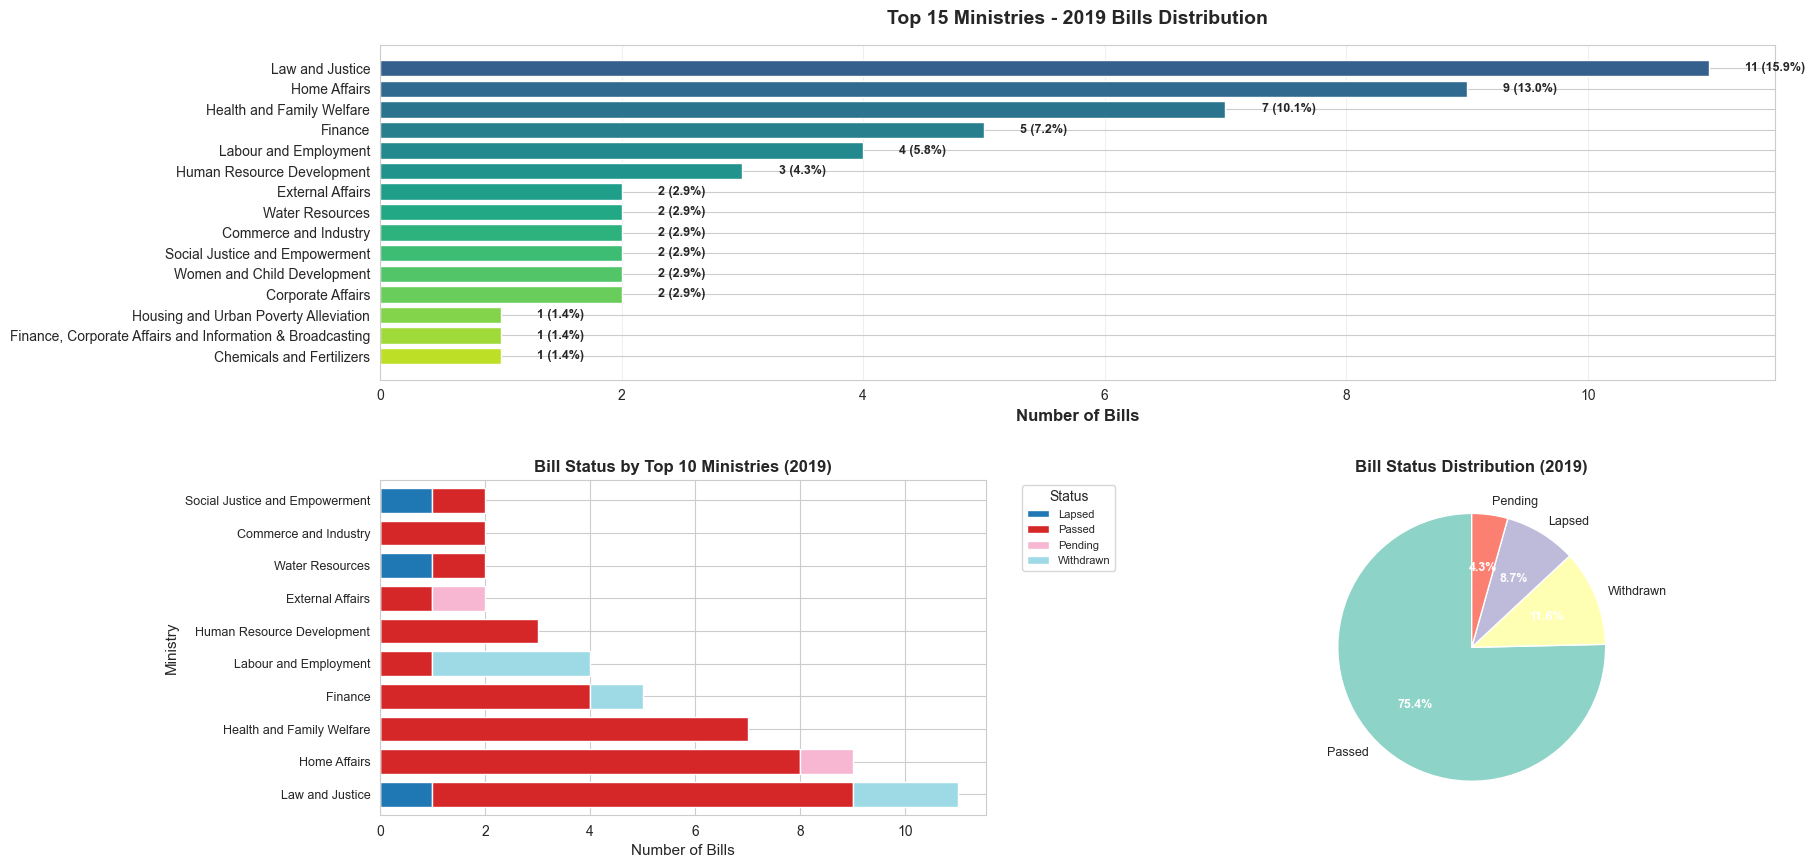


📊 2019 vs Overall Distribution Comparison:
   Top 3 Ministries in 2019:
   • Law and Justice:
     - 2019: 11 bills (15.9% of 2019)
     - Overall: 130 bills (8.5% from 2019)
   • Home Affairs:
     - 2019: 9 bills (13.0% of 2019)
     - Overall: 70 bills (12.9% from 2019)
   • Health and Family Welfare:
     - 2019: 7 bills (10.1% of 2019)
     - Overall: 26 bills (26.9% from 2019)

📝 Content Statistics for 2019 Bills:
   • Bills with content: 69 / 69 (100.0%)
   • Average content length: 5868 characters
   • Median content length: 4123 characters


In [ ]:
print("🏛️ MINISTRY-WISE DISTRIBUTION FOR 2019 BILLS")
print("="*60)

# Filter bills from 2019
bills_2019 = df_bills[df_bills['year'] == 2019]

if len(bills_2019) > 0:
    print(f"\n📊 2019 Bills Overview:")
    print(f"   • Total bills in 2019: {len(bills_2019)}")
    print(f"   • Bills with known ministry: {(bills_2019['ministry_clean'] != 'Unknown').sum()}")
    print(f"   • Unique ministries: {bills_2019[bills_2019['ministry_clean'] != 'Unknown']['ministry_clean'].nunique()}")
    
    # Ministry distribution for 2019
    ministry_2019 = bills_2019[bills_2019['ministry_clean'] != 'Unknown']['ministry_clean'].value_counts()
    
    print(f"\n📊 Top 15 Ministries in 2019:")
    for i, (ministry, count) in enumerate(ministry_2019.head(15).items(), 1):
        percentage = (count / len(bills_2019)) * 100
        print(f"   {i:2d}. {ministry}: {count} bills ({percentage:.1f}%)")
    
    # Status distribution for 2019 bills
    status_2019 = bills_2019['status'].value_counts()
    print(f"\n📊 Status Distribution of 2019 Bills:")
    for status, count in status_2019.head(5).items():
        percentage = (count / len(bills_2019)) * 100
        print(f"   • {status}: {count} bills ({percentage:.1f}%)")
    
    # Create visualizations
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # 1. Top 15 Ministries in 2019 - Horizontal Bar Chart
    ax1 = fig.add_subplot(gs[0, :])
    top_15_ministries_2019 = ministry_2019.head(15)
    colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15_ministries_2019)))
    bars = ax1.barh(range(len(top_15_ministries_2019)), top_15_ministries_2019.values, color=colors_gradient)
    ax1.set_yticks(range(len(top_15_ministries_2019)))
    ax1.set_yticklabels(top_15_ministries_2019.index, fontsize=10)
    ax1.set_xlabel('Number of Bills', fontsize=12, fontweight='bold')
    ax1.set_title('Top 15 Ministries - 2019 Bills Distribution', fontsize=14, fontweight='bold', pad=15)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, top_15_ministries_2019.values)):
        ax1.text(value + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{value} ({value/len(bills_2019)*100:.1f}%)', 
                va='center', fontsize=9, fontweight='bold')
    
    # 2. Ministry vs Status for 2019 - Stacked Bar Chart
    ax2 = fig.add_subplot(gs[1, 0])
    top_10_ministries_2019 = ministry_2019.head(10).index
    ministry_status_2019 = pd.crosstab(
        bills_2019[bills_2019['ministry_clean'].isin(top_10_ministries_2019)]['ministry_clean'],
        bills_2019['status']
    )
    ministry_status_2019.loc[top_10_ministries_2019].plot(
        kind='barh', 
        stacked=True, 
        ax=ax2, 
        colormap='tab20',
        width=0.75
    )
    ax2.set_title('Bill Status by Top 10 Ministries (2019)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Number of Bills', fontsize=11)
    ax2.set_ylabel('Ministry', fontsize=11)
    ax2.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.tick_params(axis='y', labelsize=9)
    
    # 3. Status Distribution Pie Chart for 2019
    ax3 = fig.add_subplot(gs[1, 1])
    top_statuses_2019 = status_2019.head(6)
    colors_pie = plt.cm.Set3(range(len(top_statuses_2019)))
    wedges, texts, autotexts = ax3.pie(
        top_statuses_2019.values, 
        labels=top_statuses_2019.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_pie,
        textprops={'fontsize': 9}
    )
    ax3.set_title('Bill Status Distribution (2019)', fontsize=12, fontweight='bold')
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.savefig('eda_output/ministry_distribution_2019.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_output/ministry_distribution_2019.png")
    plt.show()
    
    # Comparison with overall distribution
    print(f"\n📊 2019 vs Overall Distribution Comparison:")
    print(f"   Top 3 Ministries in 2019:")
    for ministry, count in ministry_2019.head(3).items():
        overall_count = df_bills[df_bills['ministry_clean'] == ministry].shape[0]
        print(f"   • {ministry}:")
        print(f"     - 2019: {count} bills ({count/len(bills_2019)*100:.1f}% of 2019)")
        print(f"     - Overall: {overall_count} bills ({count/overall_count*100:.1f}% from 2019)")
    
    # Content statistics for 2019 bills
    bills_2019_with_content = bills_2019[bills_2019['has_content'] == True]
    if len(bills_2019_with_content) > 0:
        print(f"\n📝 Content Statistics for 2019 Bills:")
        print(f"   • Bills with content: {len(bills_2019_with_content)} / {len(bills_2019)} ({len(bills_2019_with_content)/len(bills_2019)*100:.1f}%)")
        print(f"   • Average content length: {bills_2019_with_content['content_length'].mean():.0f} characters")
        print(f"   • Median content length: {bills_2019_with_content['content_length'].median():.0f} characters")
    
else:
    print("\n⚠️ No bills found for 2019.")

## 10. Bill Types Analysis: Law and Justice & Home Affairs (2019)

📋 BILL TYPES ANALYSIS: LAW AND JUSTICE & HOME AFFAIRS (2019)

📊 Overview:
   • Law and Justice (2019): 11 bills
   • Home Affairs (2019): 9 bills
   • Combined: 20 bills

🏛️ LAW AND JUSTICE MINISTRY - 2019 BILLS

📋 All 11 Bills:

1. 🔙 The Personal Data Protection Bill, 2019
   • Status: Withdrawn
   • Introduced: 2019-12-11
   • Content Length: 6,156 characters

2. ✅ The Constitution (One Hundred and Twenty-Sixth Amendment) Bill, 2019
   • Status: Passed
   • Introduced: 2019-12-09
   • Content Length: 1,337 characters

3. 🔙 The Jammu and Kashmir Reservation (Second Amendment) Bill, 2019
   • Status: Withdrawn
   • Introduced: 2019-08-05
   • Content Length: 1,874 characters

4. ✅ The Supreme Court (Number of Judges) Amendment Bill, 2019
   • Status: Passed
   • Introduced: 2019-08-05
   • Content Length: 1,028 characters

5. ✅ The Repealing and Amending Bill, 2019
   • Status: Passed
   • Introduced: 2019-07-25
   • Content Length: 1,320 characters

6. ✅ The Arbitration and Conciliati

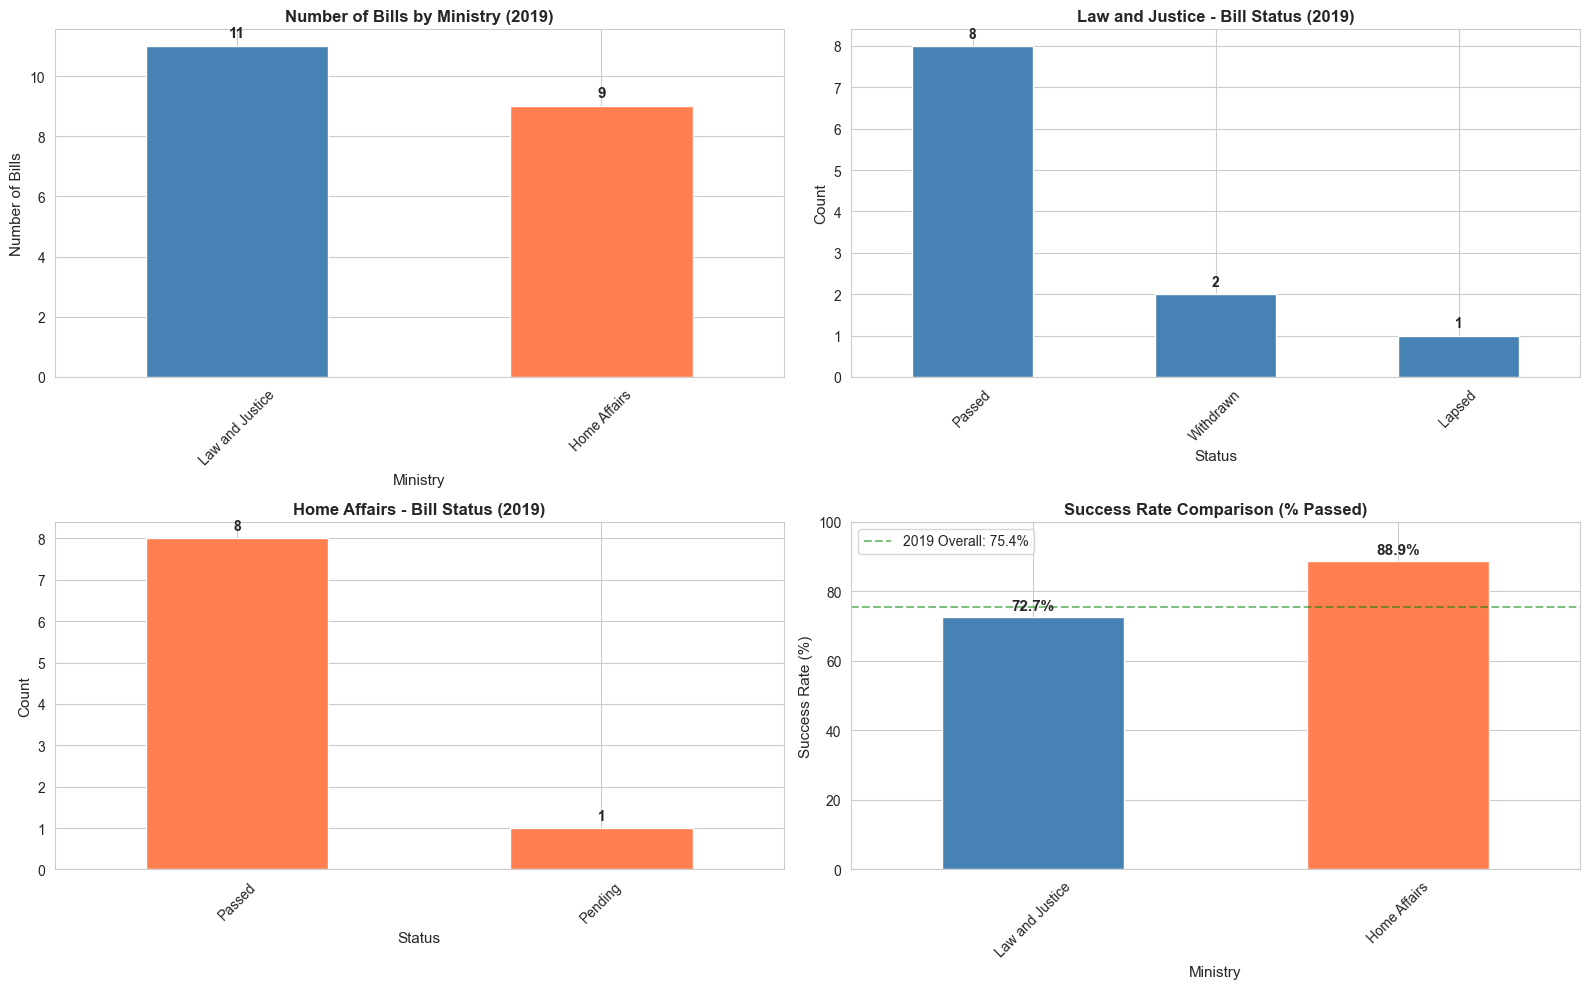


🎯 KEY INSIGHTS

1️⃣ Legislative Focus:
   • Law and Justice focused on 11 bills (legal reforms, amendments)
   • Home Affairs introduced 9 bills (security, citizenship, law enforcement)

2️⃣ Success Comparison:
   • Home Affairs had higher success rate (88.9% vs 72.7%)

3️⃣ Content Complexity:
   • Home Affairs bills were 48.7% longer on average
     (suggesting more detailed security/administrative provisions)

4️⃣ Overall Performance:
   • Combined 20 bills from these two ministries
   • Represents 29.0% of all 2019 bills
   • Both are critical governance ministries with high legislative activity


In [ ]:
print("📋 BILL TYPES ANALYSIS: LAW AND JUSTICE & HOME AFFAIRS (2019)")
print("="*70)

# Filter 2019 bills for the two ministries
law_justice_2019 = df_bills[(df_bills['year'] == 2019) & (df_bills['ministry_clean'] == 'Law and Justice')]
home_affairs_2019 = df_bills[(df_bills['year'] == 2019) & (df_bills['ministry_clean'] == 'Home Affairs')]

print(f"\n📊 Overview:")
print(f"   • Law and Justice (2019): {len(law_justice_2019)} bills")
print(f"   • Home Affairs (2019): {len(home_affairs_2019)} bills")
print(f"   • Combined: {len(law_justice_2019) + len(home_affairs_2019)} bills")

# Analyze Law and Justice bills
if len(law_justice_2019) > 0:
    print(f"\n" + "="*70)
    print("🏛️ LAW AND JUSTICE MINISTRY - 2019 BILLS")
    print("="*70)
    
    print(f"\n📋 All {len(law_justice_2019)} Bills:")
    for idx, (_, bill) in enumerate(law_justice_2019.iterrows(), 1):
        status_emoji = "✅" if bill['status'] == "Passed" else "⏸️" if bill['status'] == "Pending" else "❌" if bill['status'] == "Lapsed" else "🔙"
        print(f"\n{idx}. {status_emoji} {bill['title']}")
        print(f"   • Status: {bill['status']}")
        print(f"   • Introduced: {bill['introduction_date'][:10] if pd.notna(bill['introduction_date']) else 'N/A'}")
        print(f"   • Content Length: {bill['content_length']:,} characters" if pd.notna(bill['content_length']) else "   • Content: Not available")
    
    # Status breakdown
    lj_status = law_justice_2019['status'].value_counts()
    print(f"\n📊 Status Breakdown:")
    for status, count in lj_status.items():
        print(f"   • {status}: {count} bills ({count/len(law_justice_2019)*100:.1f}%)")

# Analyze Home Affairs bills
if len(home_affairs_2019) > 0:
    print(f"\n" + "="*70)
    print("🏠 HOME AFFAIRS MINISTRY - 2019 BILLS")
    print("="*70)
    
    print(f"\n📋 All {len(home_affairs_2019)} Bills:")
    for idx, (_, bill) in enumerate(home_affairs_2019.iterrows(), 1):
        status_emoji = "✅" if bill['status'] == "Passed" else "⏸️" if bill['status'] == "Pending" else "❌" if bill['status'] == "Lapsed" else "🔙"
        print(f"\n{idx}. {status_emoji} {bill['title']}")
        print(f"   • Status: {bill['status']}")
        print(f"   • Introduced: {bill['introduction_date'][:10] if pd.notna(bill['introduction_date']) else 'N/A'}")
        print(f"   • Content Length: {bill['content_length']:,} characters" if pd.notna(bill['content_length']) else "   • Content: Not available")
    
    # Status breakdown
    ha_status = home_affairs_2019['status'].value_counts()
    print(f"\n📊 Status Breakdown:")
    for status, count in ha_status.items():
        print(f"   • {status}: {count} bills ({count/len(home_affairs_2019)*100:.1f}%)")

# Comparative Analysis
print(f"\n" + "="*70)
print("📊 COMPARATIVE ANALYSIS")
print("="*70)

# Success rates
if len(law_justice_2019) > 0:
    lj_passed = (law_justice_2019['status'] == 'Passed').sum()
    lj_success_rate = (lj_passed / len(law_justice_2019)) * 100
    print(f"\n🏛️ Law and Justice:")
    print(f"   • Total Bills: {len(law_justice_2019)}")
    print(f"   • Passed: {lj_passed} ({lj_success_rate:.1f}%)")
    print(f"   • Average Content Length: {law_justice_2019['content_length'].mean():.0f} characters")

if len(home_affairs_2019) > 0:
    ha_passed = (home_affairs_2019['status'] == 'Passed').sum()
    ha_success_rate = (ha_passed / len(home_affairs_2019)) * 100
    print(f"\n🏠 Home Affairs:")
    print(f"   • Total Bills: {len(home_affairs_2019)}")
    print(f"   • Passed: {ha_passed} ({ha_success_rate:.1f}%)")
    print(f"   • Average Content Length: {home_affairs_2019['content_length'].mean():.0f} characters")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Bill Count Comparison
ax1 = axes[0, 0]
ministry_counts = pd.Series({
    'Law and Justice': len(law_justice_2019),
    'Home Affairs': len(home_affairs_2019)
})
ministry_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title('Number of Bills by Ministry (2019)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Bills', fontsize=11)
ax1.set_xlabel('Ministry', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(ministry_counts):
    ax1.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')

# 2. Status Distribution - Law and Justice
ax2 = axes[0, 1]
if len(law_justice_2019) > 0:
    lj_status.plot(kind='bar', ax=ax2, color='steelblue')
    ax2.set_title('Law and Justice - Bill Status (2019)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_xlabel('Status', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)
    for i, v in enumerate(lj_status):
        ax2.text(i, v + 0.2, str(v), ha='center', fontsize=10, fontweight='bold')

# 3. Status Distribution - Home Affairs
ax3 = axes[1, 0]
if len(home_affairs_2019) > 0:
    ha_status.plot(kind='bar', ax=ax3, color='coral')
    ax3.set_title('Home Affairs - Bill Status (2019)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=11)
    ax3.set_xlabel('Status', fontsize=11)
    ax3.tick_params(axis='x', rotation=45)
    for i, v in enumerate(ha_status):
        ax3.text(i, v + 0.2, str(v), ha='center', fontsize=10, fontweight='bold')

# 4. Success Rate Comparison
ax4 = axes[1, 1]
success_rates = pd.Series({
    'Law and Justice': lj_success_rate if len(law_justice_2019) > 0 else 0,
    'Home Affairs': ha_success_rate if len(home_affairs_2019) > 0 else 0
})
success_rates.plot(kind='bar', ax=ax4, color=['steelblue', 'coral'])
ax4.set_title('Success Rate Comparison (% Passed)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Success Rate (%)', fontsize=11)
ax4.set_xlabel('Ministry', fontsize=11)
ax4.set_ylim(0, 100)
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=75.4, color='green', linestyle='--', alpha=0.5, label='2019 Overall: 75.4%')
ax4.legend()
for i, v in enumerate(success_rates):
    ax4.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_output/law_justice_home_affairs_2019.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: eda_output/law_justice_home_affairs_2019.png")
plt.show()

# Key Insights
print(f"\n" + "="*70)
print("🎯 KEY INSIGHTS")
print("="*70)
print(f"\n1️⃣ Legislative Focus:")
print(f"   • Law and Justice focused on {len(law_justice_2019)} bills (legal reforms, amendments)")
print(f"   • Home Affairs introduced {len(home_affairs_2019)} bills (security, citizenship, law enforcement)")

if len(law_justice_2019) > 0 and len(home_affairs_2019) > 0:
    print(f"\n2️⃣ Success Comparison:")
    if lj_success_rate > ha_success_rate:
        print(f"   • Law and Justice had higher success rate ({lj_success_rate:.1f}% vs {ha_success_rate:.1f}%)")
    elif ha_success_rate > lj_success_rate:
        print(f"   • Home Affairs had higher success rate ({ha_success_rate:.1f}% vs {lj_success_rate:.1f}%)")
    else:
        print(f"   • Both ministries had equal success rates ({lj_success_rate:.1f}%)")
    
    print(f"\n3️⃣ Content Complexity:")
    lj_avg = law_justice_2019['content_length'].mean()
    ha_avg = home_affairs_2019['content_length'].mean()
    if lj_avg > ha_avg:
        print(f"   • Law and Justice bills were {((lj_avg/ha_avg - 1) * 100):.1f}% longer on average")
        print(f"     (suggesting more complex legal frameworks)")
    else:
        print(f"   • Home Affairs bills were {((ha_avg/lj_avg - 1) * 100):.1f}% longer on average")
        print(f"     (suggesting more detailed security/administrative provisions)")

print(f"\n4️⃣ Overall Performance:")
print(f"   • Combined {len(law_justice_2019) + len(home_affairs_2019)} bills from these two ministries")
print(f"   • Represents {((len(law_justice_2019) + len(home_affairs_2019))/69)*100:.1f}% of all 2019 bills")
print(f"   • Both are critical governance ministries with high legislative activity")

## 12. Search Analytics

🔍 SEARCH ANALYTICS

Total Searches: 57
Unique Keywords: 9
Average Results per Search: 7.6

📊 Top 10 Search Keywords:
keyword
gaming          22
tax             21
vehicle          4
anti             4
finance          2
constitution     1
regulation       1
bike             1
tX               1
Name: count, dtype: int64



✅ Saved: eda_output/top_search_keywords.png


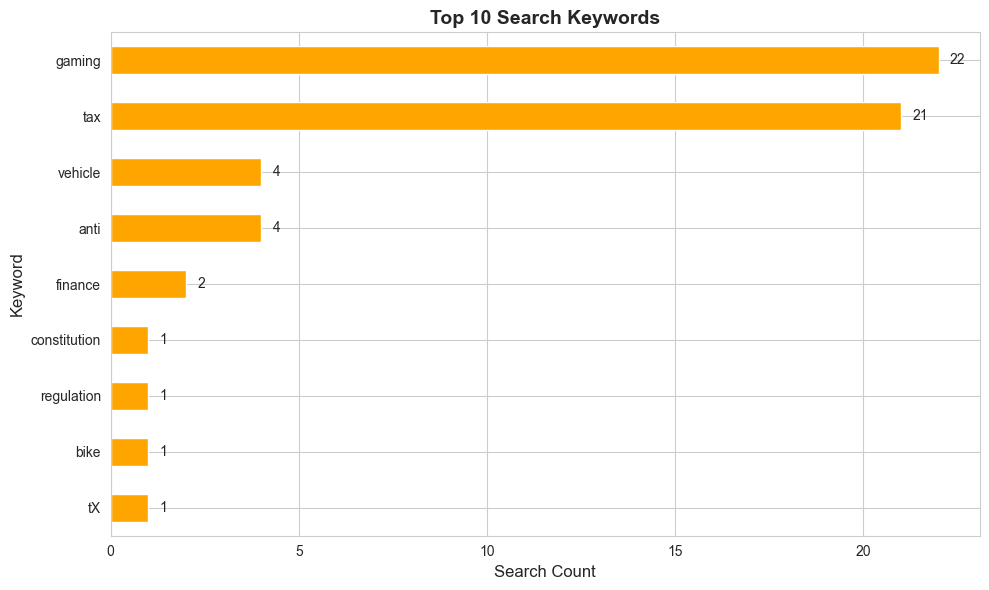


📈 Search Results Statistics:
count    57.000000
mean      7.596491
std      10.446906
min       0.000000
25%       1.000000
50%       2.000000
75%      11.000000
max      37.000000
Name: results_count, dtype: float64


In [ ]:
print("🔍 SEARCH ANALYTICS")
print("="*60)

if len(df_searches) > 0:
    print(f"\nTotal Searches: {len(df_searches)}")
    print(f"Unique Keywords: {df_searches['keyword'].nunique()}")
    print(f"Average Results per Search: {df_searches['results_count'].mean():.1f}")
    
    # Top search terms
    top_keywords = df_searches['keyword'].value_counts().head(10)
    print("\n📊 Top 10 Search Keywords:")
    print(top_keywords)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    top_keywords.plot(kind='barh', ax=ax, color='orange')
    ax.set_title('Top 10 Search Keywords', fontsize=14, fontweight='bold')
    ax.set_xlabel('Search Count', fontsize=12)
    ax.set_ylabel('Keyword', fontsize=12)
    ax.invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_keywords):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('eda_output/top_search_keywords.png', dpi=300, bbox_inches='tight')
    print("\n✅ Saved: eda_output/top_search_keywords.png")
    plt.show()
    
    # Results distribution
    print("\n📈 Search Results Statistics:")
    print(df_searches['results_count'].describe())
else:
    print("\n⚠️ No search history data found.")